# 11 — Facade & Terrain Analysis

The four raytraced solar-family models (`sky-view-factors`, `solar-radiation`,
`direct-sun-hours`, `daylight-availability`) can analyse **building surfaces**
(facades, roofs) or **arbitrary sensor points** instead of the default
512×512 ground grid. Requires `infrared-sdk >= 0.4.12`.

**A facade request returns a different result type.** Instead of an
`AreaResult` with a `merged_grid`, you get a `SurfaceAnalysisResult`:

| Attribute | Contents |
|---|---|
| `surfaces` | `{"<building-id>/<surface-index>": SurfaceSensorGrid}` — per-surface UV sensor grids |
| `aggregates["buildings"]` | `{building_id: BuildingAggregate}` — per-building `area` / `mean` / `peak` |
| `sensor_count` | total sensors across all surfaces |
| `min_legend` / `max_legend` | colour-scale bounds |

This notebook runs a facade sky-view-factor analysis on real fetched
buildings, then a bring-your-own-sensor-points run, and shows the
terrain-draping fields.

In [1]:
from dotenv import load_dotenv

load_dotenv()

from infrared_sdk import InfraredClient, SurfaceAnalysisResult
from infrared_sdk.analyses.types import AnalysesName, SvfModelRequest
from cities import get

city = get("munich")

client = InfraredClient()
area = client.buildings.get_area(city.polygon_small)
print(f"Found {area.total_buildings} buildings.")

No base_url provided and INFRARED_BASE_URL env var not set; falling back to DEFAULT_BASE_URL (https://api.infrared.city/v2)


[INFO] [SDK:BigPayload] route=inline url=https://api.infrared.city/v2/buildings raw_bytes=188 threshold=5242880 enabled=True


[INFO] [SDK:BigPayload] inline ok url=https://api.infrared.city/v2/buildings status=200 elapsed_ms=2491 response_bytes=868351 x-amzn-requestid=1954b6a7-446e-4748-bee5-5918e5a44fea


Found 329 buildings.


## 1. Facade analysis on fetched buildings

Set `analysis_surfaces="facades"` (or `"roofs"` / `"all"`) and a
`surface_grid_size` (sensor spacing in metres, minimum 0.25). The server
synthesises a sensor grid on every matching surface of every building.

In [2]:
payload = SvfModelRequest(
    analysis_type=AnalysesName.sky_view_factors,
    analysis_surfaces="facades",
    surface_grid_size=2.0,
)

result = client.run_area_and_wait(payload, city.polygon_small, buildings=area.buildings)

assert isinstance(result, SurfaceAnalysisResult)
print(f"{len(result.surfaces)} surfaces, {result.sensor_count} sensors")
print(f"legend bounds: [{result.min_legend}, {result.max_legend}]")

[INFO] [SDK:Area] run_area start phase=initial analyses=sky-view-factors max_workers=20 max_tiles_override=None buildings=yes vegetation=no ground_materials=no


[INFO] [SDK:Area] run_area tiled non_empty_tiles=1 grid=1x1


[INFO] [SDK:Layers] resolve_layers non_empty_tiles=1 buildings_in=329 vegetation_in=0 ground_materials_in=0


[INFO] [SDK:Area] run_area_single phase=initial analysis=sky-view-factors non_empty_tiles=1 retry_filter_size=0 config_hash=96c205c80534


[INFO] [SDK:Area] run_area_single phase=initial analysis=sky-view-factors tile_payloads_built=1


...

[INFO] [SDK:Polling] check_area_state analysis=sky-view-factors counts={'Pending': 1} is_complete=False


[INFO] [SDK:Polling] check_area_state analysis=sky-view-factors counts={'Succeeded': 1} is_complete=True


[INFO] [SDK:Polling] check_area_state analysis=sky-view-factors counts={'Succeeded': 1} is_complete=True


[INFO] [SDK:Merge] merge_surface_area_jobs analysis=sky-view-factors jobs_total=1 mode=surface-union


3212 surfaces, 107477 sensors
legend bounds: [0.0, 100.0]


In [3]:
# Per-building aggregates: mean / peak SVF over each building's facades.
buildings_agg = result.aggregates["buildings"]
top5 = sorted(buildings_agg.items(), key=lambda kv: kv[1].area, reverse=True)[:5]
for building_id, agg in top5:
    print(
        f"{building_id:>12}  area={agg.area:8.1f} m²  "
        f"mean SVF={agg.mean:5.1f}  peak={agg.peak:5.1f}"
    )

ed86d808-e079-47db-b726-17e263def095  area= 28620.0 m²  mean SVF= 25.6  peak= 49.7
33e9dbb4-5e90-4e18-9f83-428ad4fa2b08  area= 24128.0 m²  mean SVF= 39.1  peak= 49.7
dd0a9414-9b53-4a67-8eec-4a69bc593e43  area= 22620.0 m²  mean SVF= 43.4  peak= 49.7
0e31ff4c-c33b-4d90-b3ce-d51add361d33  area= 12764.0 m²  mean SVF= 44.1  peak= 49.7
73c9bb5d-f891-4f73-9a9d-ea482375fafc  area= 12492.0 m²  mean SVF= 35.9  peak= 49.7


## 2. Looking at one surface

Each `SurfaceSensorGrid` is a small `nu × nv` grid in the surface's own
UV frame: `origin` is the frame anchor in tile metres, `u_axis` / `v_axis`
are the in-plane directions, and `values` holds `nu * nv` sensor values.
Cells outside the surface footprint are masked — they come back as
`None`; map them to `NaN` for plotting.

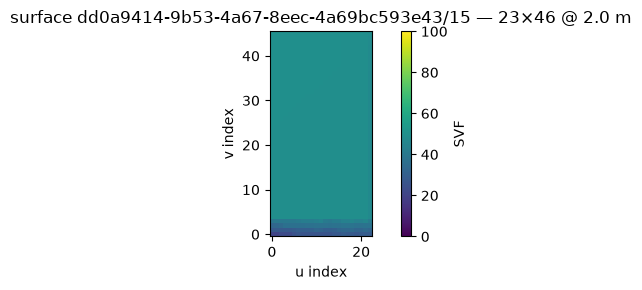

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Pick the largest single surface for a look.
key, surface = max(result.surfaces.items(), key=lambda kv: kv[1].area)
grid = np.array([v if v is not None else np.nan for v in surface.values]).reshape(
    surface.nv, surface.nu
)

fig, ax = plt.subplots(figsize=(6, 3))
im = ax.imshow(
    grid,
    origin="lower",
    vmin=result.min_legend,
    vmax=result.max_legend,
    cmap="viridis",
)
ax.set_title(f"surface {key} — {surface.nu}×{surface.nv} @ {surface.grid_size} m")
ax.set_xlabel("u index")
ax.set_ylabel("v index")
fig.colorbar(im, ax=ax, label="SVF")
plt.tight_layout()
plt.show()

## 3. Bring your own sensor points

Instead of surface synthesis, pass explicit `sensor_points` (tile-local
metres, max 100,000) with optional `sensor_normals`. Mutually exclusive
with `analysis_surfaces` — the SDK raises client-side if you set both.

**Sensor-points runs are single-tile only** and go through the low-level
job primitives, not `run_area_and_wait` (which rejects them). The result
is a flat per-sensor list under `"output"` — one value per sensor, in
your input order — not a grid and not a `SurfaceAnalysisResult`.

In [5]:
# Two sensors near the largest surface's anchor, at 1.5 m and 4.5 m height.
origin = surface.origin
byo = SvfModelRequest(
    analysis_type=AnalysesName.sky_view_factors,
    geometries=area.buildings,
    sensor_points=[
        [origin[0], origin[1], 1.5],
        [origin[0], origin[1], 4.5],
    ],
    sensor_normals=[[0.0, -1.0, 0.0], [0.0, -1.0, 0.0]],
)

job = client.analyses.execute(payload=byo)
completed = client.jobs.wait_for_completion(job.job_id, timeout=120)
download = client.jobs.download_results(completed.job_id)
byo_result = client.jobs.decompress(download.content)

print(f"{byo_result['sensor-count']} sensors -> {byo_result['output']}")

[INFO] [SDK:Submit] analysis=sky-view-factors url=https://api.infrared.city/v2/async/sky-view-factors raw_json_bytes=1013208 zip_bytes=99579


[INFO] [SDK:Submit] analysis=sky-view-factors ok job_id=337d94e0-f2c0-4be8-a3af-93cec051b78b elapsed_ms=386


2 sensors -> [21.375, 30.625]


## 4. Terrain draping

All six raytraced models (the four solar-family ones **plus**
`thermal-comfort-index` / `thermal-comfort-statistics`) accept terrain
fields — results drape over the ground mesh instead of assuming z=0:

```python
payload = SvfModelRequest(
    analysis_type=AnalysesName.sky_view_factors,
    ground_geometry={"terrain": terrain_mesh},   # DotBim-style mesh
    terrain_alignment="auto-align",              # or "assume-aligned"
)
```

Terrain-only requests return the normal grid result — only
`analysis_surfaces` / `sensor_points` switch the result type.

## Notes

- **Batching + billing:** very large facade requests (estimated sensor
  count above the server's 262,144-sensor synthesis cap) are
  transparently split into multiple sub-jobs and merged back into one
  `SurfaceAnalysisResult`. **Each sub-job is billed separately.**
- Facade fields are rejected on `thermal-comfort-index` /
  `thermal-comfort-statistics`; terrain fields work everywhere.